In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import model_hybrid as model

# Baseline Results

# List of Parameters

Agent:
- Alpha
- Gamma
- Temp

Environment:
- Number of memories
- Number of groups
- Connectivity
- Rewards
- Trauma Activation
- Decay
- Delta (Additional Memories Presented)


In [29]:
def run_experiment(
    # Environment parameters
    n=100,
    groups=5,
    rewards=None,
    thres=0,
    in_group=10,
    trauma=(0, 10),
    # Simulator / decay parameters
    runs=50,
    max_steps=100,
    time=10,
    delta=20,
    a=0.1,
    # Agent parameters (HybridAgent)
    alpha=0.1,
    gamma=0.9,
    temp=0.1,
    bias=0.5,
    # Repetitions for averaging
    rep=10,
):
    """
    Run the hybrid agent experiment with the given parameters and return
    average and final retrieval lengths across `rep` repetitions.

    Parameters
    ----------
    n : int
        Number of memories.
    groups : int
        Number of groups.
    rewards : dict or None
        Reward mapping {node_index: reward}. If None, defaults to all 1s
        with the trauma node (trauma[0]) set to -100.
    thres : float
        Spreading-activation threshold; activations below this are zeroed.
    in_group : float
        Base weight for within-group edges.
    trauma : tuple
        (trauma_node_index, trauma_activation_boost).
    runs : int
        Number of retrieval episodes per repetition.
    max_steps : int
        Maximum steps per retrieval episode.
    time : float
        Decay time added to traces after each retrieval (controls forgetting rate).
    delta : int or None
        Number of additional memories added after each retrieval. None = no addition.
    a : float
        Initial activation value for newly added memories.
    connectivity : float or None
        Noise sigma for spreading activation (Memory.sigma). Uses model default if None.
    alpha : float
        Agent learning rate.
    gamma : float
        Agent discount factor.
    temp : float
        Softmax temperature for the recall decision gate.
    bias : float
        HybridAgent mixing weight: 0 = pure QAgent, 1 = pure Agent.
    rep : int
        Number of independent repetitions to average over.

    Returns
    -------
    dict with keys:
        "avg_retrieval_length"   : float  — mean of per-rep average retrieval lengths
        "final_retrieval_length" : float  — mean of per-rep final retrieval lengths
    """
    rep_avg = []
    rep_final = []
    rep_individual = []
    rep_value = []
    rep_vtable = []

    for _ in range(rep):
        # Build default rewards if not provided
        if rewards is None:
            r = {i: 1 for i in range(n)}
            if trauma[0] is not None:
                r[trauma[0]] = -100
        else:
            r = rewards

        # Construct environment
        env_kwargs = dict(thres=thres, in_group=in_group, trauma=trauma)
        environment = model.Memory(n, groups, r, **env_kwargs)

        # Construct agent
        agent = model.HybridAgent(
            environment, alpha=alpha, gamma=gamma, temp=temp, bias=bias
        )

        # Run simulation
        sim = model.Simulator(agent, environment)
        sim.run(runs, max_steps, time=time, delta=delta, a=a)

        retrieval_lengths = [len(trial) for trial in sim.record]
        rep_avg.append(np.mean(retrieval_lengths))
        rep_final.append(retrieval_lengths[-1])
        rep_individual.append(retrieval_lengths)
        rep_value.append(agent.value)
        rep_vtable.append(np.mean(list(agent.vtable.values())))

    return {
        "avg_retrieval_length": float(np.mean(rep_avg)),
        "final_retrieval_length": float(np.mean(rep_final)),
        "individual_retrieval_lengths": np.mean(np.array(rep_individual), axis=0),
        "final_value": rep_value,
        "final_vtable": rep_vtable
    }

In [30]:
def bias_experiment(bias_list, rewards, rep=50):
    data1 = []
    data2 = []
    data3 = []
    for bias in bias_list:
        result = run_experiment(bias=bias, rep=rep, rewards=rewards)
        for n, length in enumerate(result["individual_retrieval_lengths"]):
            data1.append({"bias": bias, "n": n, "retrieval length": length})
        data2.append({"bias": bias, "retrieval length": result["avg_retrieval_length"], "group": "average"})
        data2.append({"bias": bias, "retrieval length": result["final_retrieval_length"], "group": "final"})
        for run, v in enumerate(result["final_value"]):
            data3.append({"bias": bias, "run": run, "final_value": v, "final_vtable": result["final_vtable"][run]})
    return data1, data2, data3

In [31]:
def quad_plot(data, condition, n=11):
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    data1, data2, data3 = data[condition]

    # --- Plot 1: smoothed line plot ---
    df1 = pd.DataFrame(data1)
    df1["retrieval length smooth"] = (
        df1.groupby("bias")["retrieval length"]
        .transform(lambda x: x.rolling(window=5, center=True, min_periods=1).mean())
    )
    
    palette = sns.color_palette("tab10", n_colors=n)
    sns.lineplot(data=df1, x="n", y="retrieval length smooth", hue="bias",
                 palette=palette, errorbar=None, ax=axs[0, 0])
    axs[0, 0].set_ylabel("retrieval length")
    axs[0, 0].set_title("Retrieval Length over Time")
    
    # --- Plot 2: bar plot ---
    sns.barplot(data=pd.DataFrame(data2), x="bias", y="retrieval length", hue="group", ax=axs[0, 1])
    axs[0, 1].set_title("Average vs Final Retrieval Length")
    
    sns.lineplot(data=pd.DataFrame(data3), x="bias", y="final_value", ax=axs[1, 0])
    axs[1, 0].set_title("Final Value vs Bias")
    
    sns.lineplot(data=pd.DataFrame(data3), x="bias", y="final_vtable", ax=axs[1, 1])
    axs[1, 1].set_title("Final VTable vs Bias")
    
    plt.tight_layout()
    plt.savefig(f"trauma_{condition}.png")
    plt.show()

In [32]:
def trauma_comparison(data):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    for condition in data:
        df = pd.DataFrame(data[condition][2])
        sns.lineplot(data=df, x="bias", y="final_value", ax=axs[0], label=f"Trauma {condition}")
        sns.lineplot(data=df, x="bias", y="final_vtable", ax=axs[1], label=f"Trauma {condition}")
    axs[0].set_yscale('symlog')
    axs[0].set_title("Final Value vs Bias")
    axs[1].set_title("Final Vtable vs Bias")
    axs[0].legend()
    axs[1].legend()

    plt.tight_layout()
    plt.savefig("trauma_levels_over_bias.png")
    plt.show()

In [33]:
bias_data = {}
default_rewards = {i: 1 for i in range(100)}
trauma_0 = default_rewards.copy()
trauma_0[0] = -100
trauma_1 = default_rewards.copy()
trauma_1[0] = -1000
trauma_2 = trauma_1.copy()
trauma_2[0] = -10000
rewards = [trauma_0, trauma_1, trauma_2]
bias_1 = [i / 10 for i in range(0, 11)]
bias_2 = [i / 500 for i in range(0, 11)]
bias_3 = [i / 5000 for i in range(0, 11)]
biases = [bias_1, bias_2, bias_3] 
for reward, bias in zip(rewards, biases):
    bias_data[reward[0]] = bias_experiment(bias, reward, rep=50)

In [34]:
bias_data2 = {}
for reward in rewards:
    bias_data2[reward[0]] = bias_experiment([i / 100 for i in range(101)], reward, rep=5)

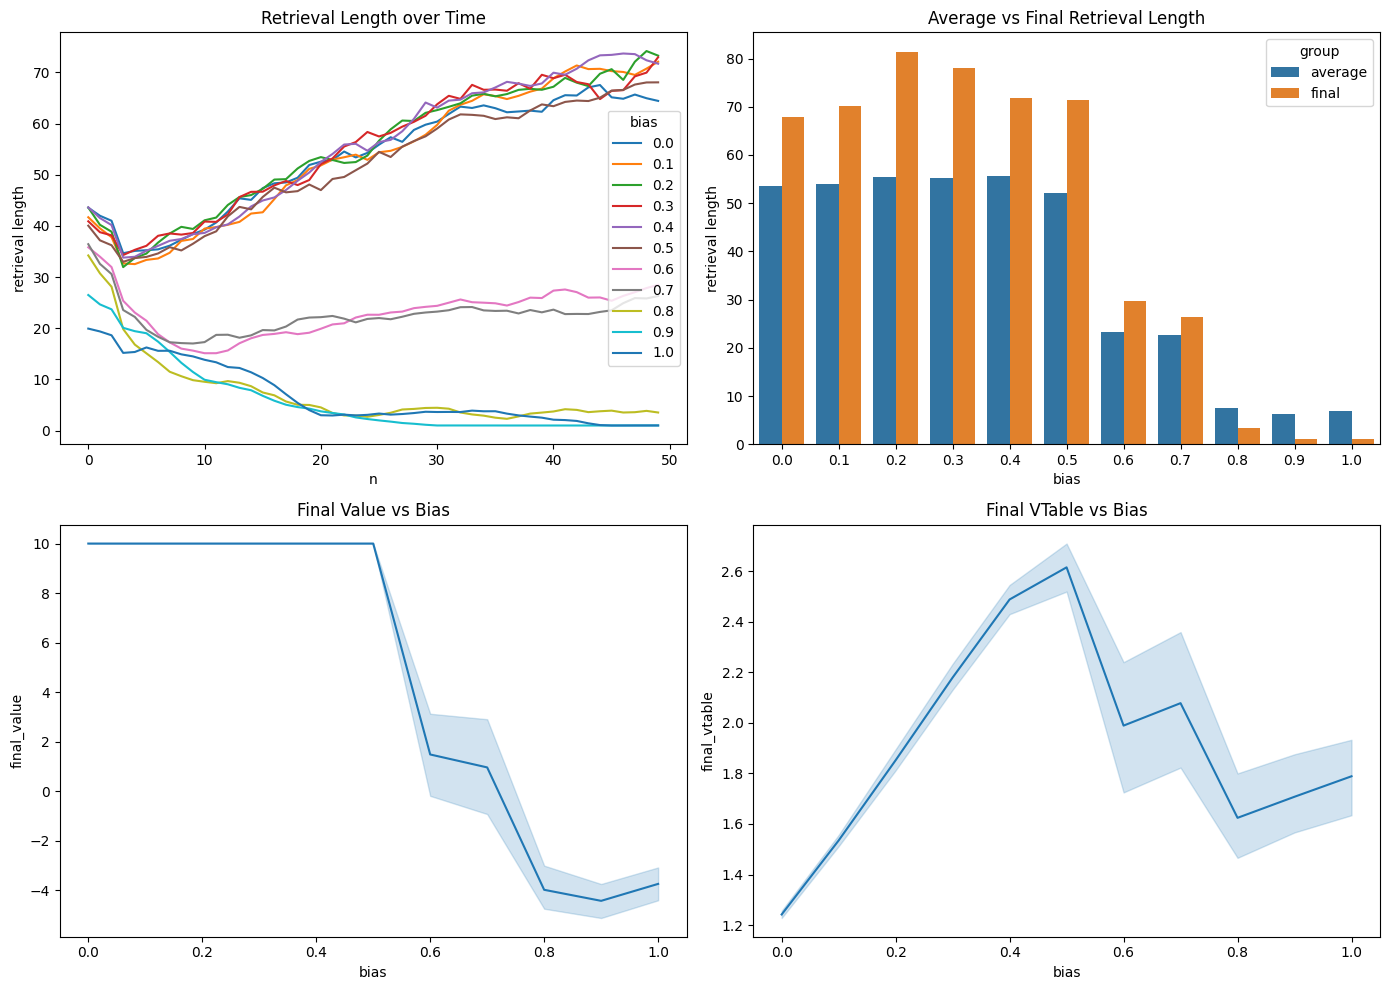

In [39]:
quad_plot(bias_data, -100, n=11)

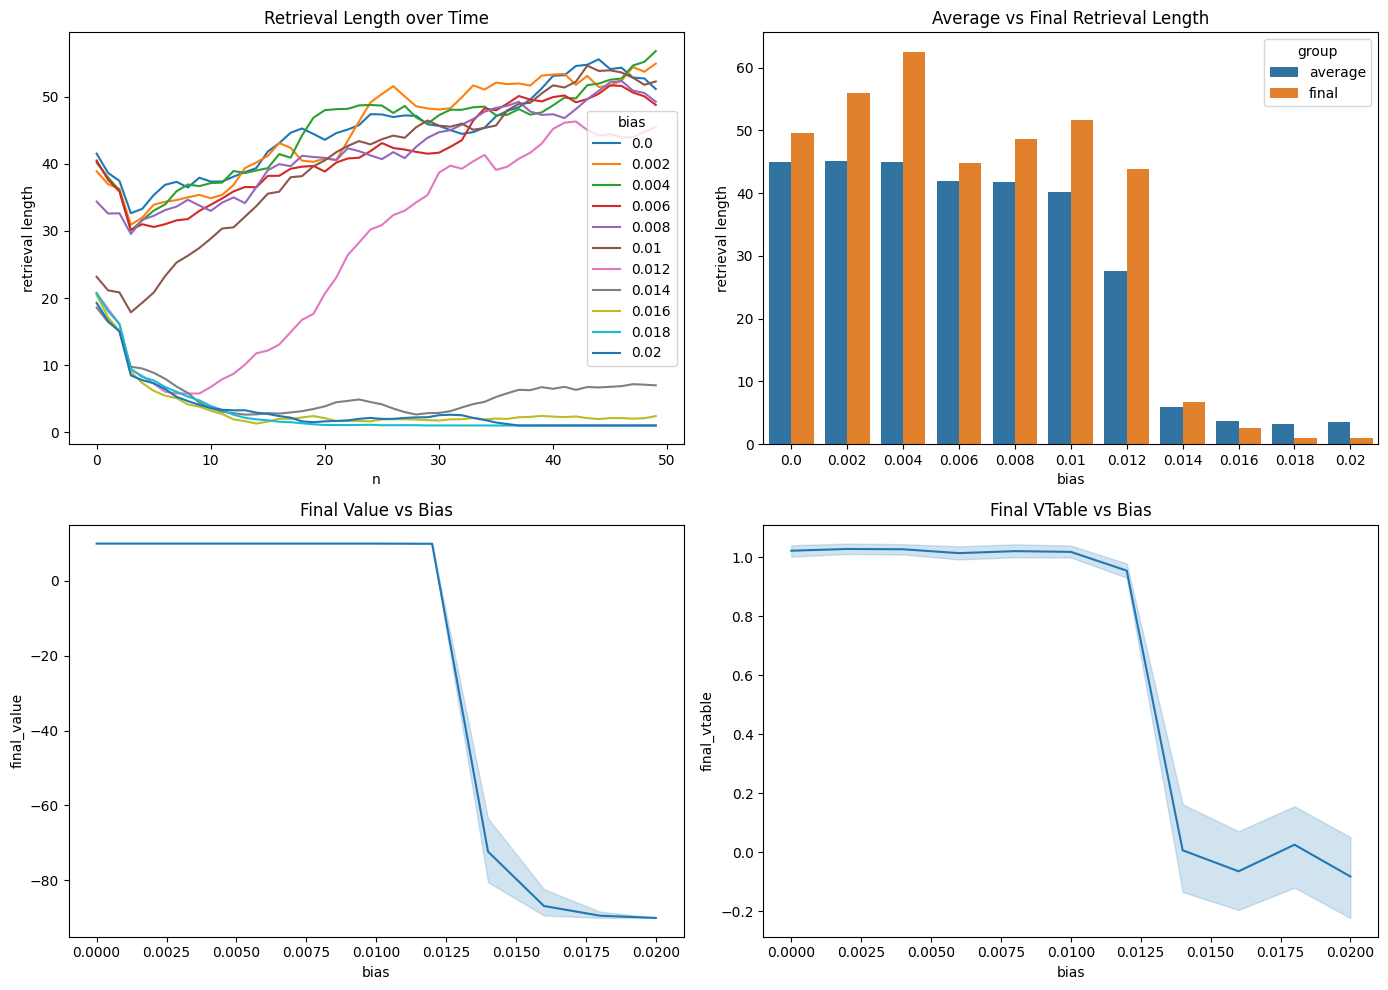

In [40]:
quad_plot(bias_data, -1000, n=11)

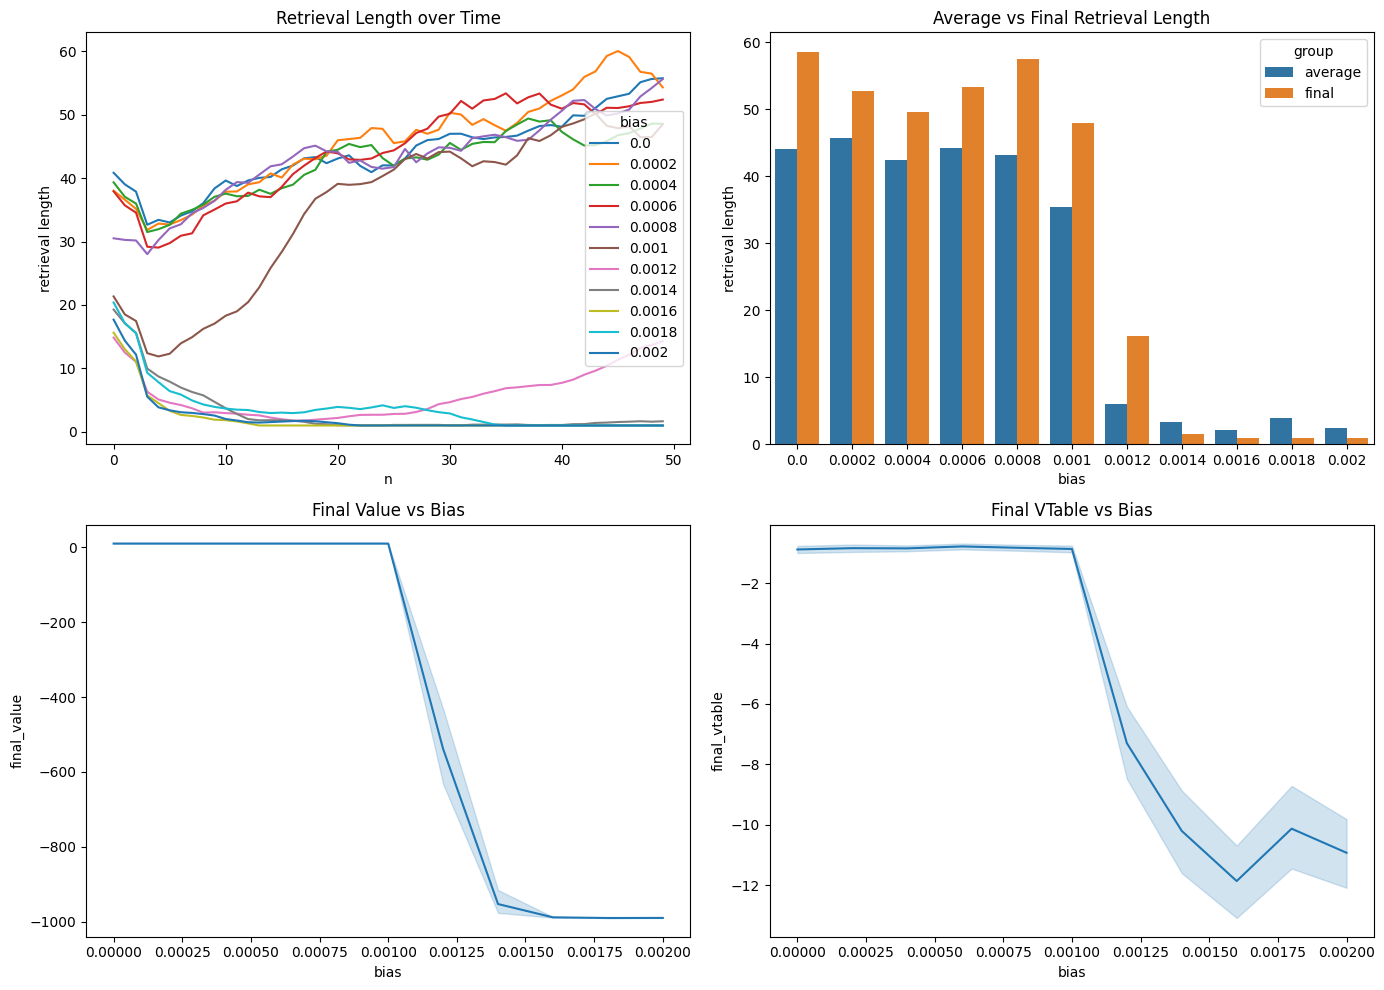

In [41]:
quad_plot(bias_data, -10000, n=11)

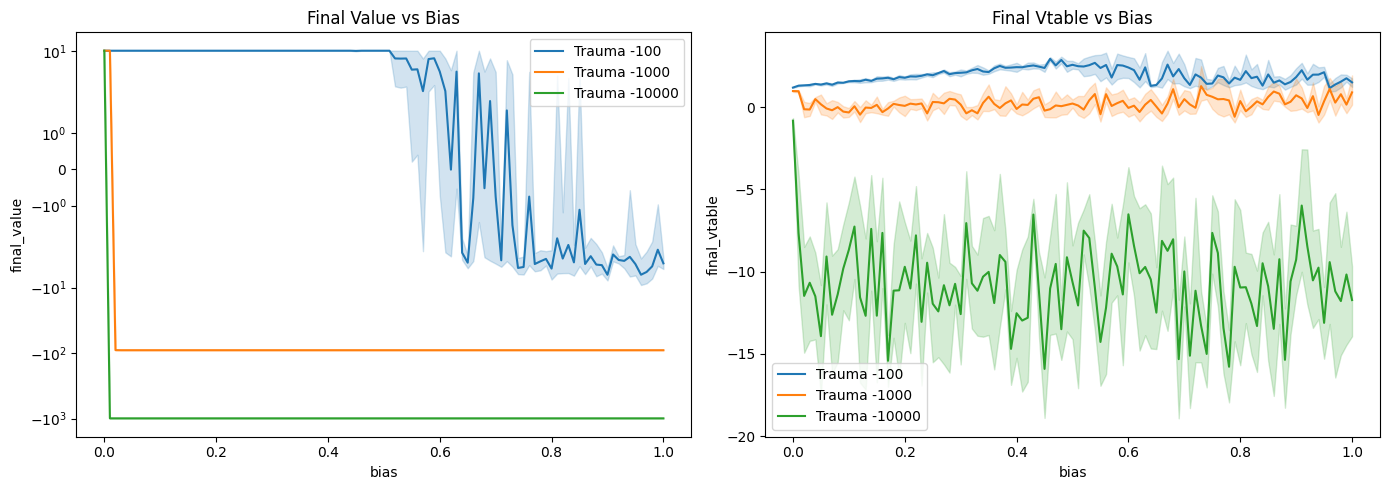

In [38]:
trauma_comparison(bias_data2)